In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/heart_disease.xlsx"
xls = pd.ExcelFile(file_path)

# Check available sheets
xls.sheet_names
# Load the description sheet
description_df = pd.read_excel(xls, sheet_name="Description")
# Display the first few rows of the description sheet
description_df.head()
# Load the heart disease dataset
heart_disease_df = pd.read_excel(xls, sheet_name="Heart_disease")
# Display basic info and first few rows
heart_disease_df.info(), heart_disease_df.head()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


(None,
    age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
 0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
 1   41  Male  atypical angina       135   203  False          normal     132   
 2   57  Male     asymptomatic       140   192  False          normal     148   
 3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
 4   57  Male     asymptomatic       110   201  False          normal     126   
 
    exang  oldpeak        slope          thal  num  
 0  False      2.3  downsloping  fixed defect    0  
 1  False      0.0         flat  fixed defect    0  
 2  False      0.4         flat  fixed defect    0  
 3  False      0.0         flat  fixed defect    0  
 4   True      1.5         flat  fixed defect    0  )

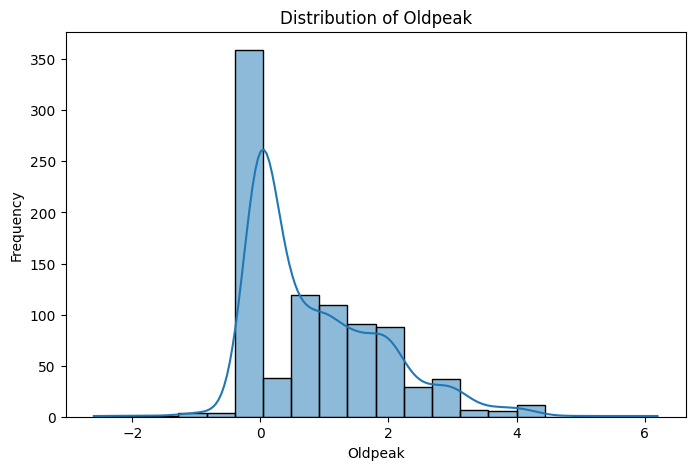

<ipython-input-6-d4c15c9151c0>:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_disease_df['oldpeak'].fillna(heart_disease_df['oldpeak'].median(), inplace=True)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,1,2.3,0,0,0
1,41,1,1,135,203,False,1,132,1,0.0,1,0,0
2,57,1,0,140,192,False,1,148,1,0.4,1,0,0
3,52,1,3,118,186,False,0,190,1,0.0,1,0,0
4,57,1,0,110,201,False,1,126,3,1.5,1,0,0


In [ ]:
# Check missing values in the dataset
missing_values = heart_disease_df.isnull().sum()
missing_values[missing_values > 0]

import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of 'oldpeak'
plt.figure(figsize=(8, 5))
sns.histplot(heart_disease_df['oldpeak'], bins=20, kde=True)
plt.xlabel('Oldpeak')
plt.ylabel('Frequency')
plt.title('Distribution of Oldpeak')
plt.show()

# Summary statistics of 'oldpeak'
heart_disease_df['oldpeak'].describe()

# Impute missing values in 'oldpeak' with the median
heart_disease_df['oldpeak'].fillna(heart_disease_df['oldpeak'].median(), inplace=True)

# Verify no missing values remain
heart_disease_df.isnull().sum().sum()

from sklearn.preprocessing import LabelEncoder

# Categorical columns to encode
categorical_cols = ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal']

# Apply label encoding
label_encoders = {}
for col in categorical_cols:
    # Convert the column to string type before encoding
    heart_disease_df[col] = heart_disease_df[col].astype(str)
    le = LabelEncoder()
    heart_disease_df[col] = le.fit_transform(heart_disease_df[col])
    label_encoders[col] = le  # Store encoders for reference


# Display the first few rows after encoding
heart_disease_df.head()


In [ ]:
# Check unique values for each categorical column
unique_values = {col: heart_disease_df[col].unique() for col in categorical_cols}
unique_values


{'sex': array([1, 0]),
 'cp': array([3, 1, 0, 2]),
 'restecg': array([0, 1, 2]),
 'exang': array([nan]),
 'slope': array([0, 1, 2]),
 'thal': array([0, 1, 2])}

In [ ]:
# Standardize 'exang' values
heart_disease_df['exang'] = heart_disease_df['exang'].astype(str).str.lower().map({'false': 0, 'true': 1, 'ture': 1})

# Verify unique values again
heart_disease_df['exang'].unique()


array([nan])

In [ ]:
# Apply label encoding to remaining categorical columns
for col in ['slope', 'thal', 'cp', 'restecg']:
    le = LabelEncoder()
    heart_disease_df[col] = le.fit_transform(heart_disease_df[col])
    label_encoders[col] = le  # Store encoders for reference

# Display the first few rows after encoding
heart_disease_df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,NaN,2.3,0,0,0
1,41,1,1,135,203,False,1,132,NaN,0.0,1,0,0
2,57,1,0,140,192,False,1,148,NaN,0.4,1,0,0
3,52,1,3,118,186,False,0,190,NaN,0.0,1,0,0
4,57,1,0,110,201,False,1,126,NaN,1.5,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Define features (X) and target (y)
X = heart_disease_df.drop(columns=['num'])  # Independent variables
y = heart_disease_df['num']  # Target variable

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set using predict_proba to get probabilities
y_pred_probs = dt_model.predict_proba(X_test)  # Get predicted probabilities
y_pred = dt_model.predict(X_test)  # Get predicted classes

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Use y_pred_probs for roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovo', average='weighted') # or multi_class='ovr'

# Print the classification report
classification_rep = classification_report(y_test, y_pred)

accuracy, precision, recall, f1, roc_auc, classification_rep

(0.4340659340659341,
 0.48465557185716335,
 0.4340659340659341,
 0.45553388771656816,
 np.float64(0.5918820731015392),
 '              precision    recall  f1-score   support\n\n           0       0.75      0.61      0.68        80\n           1       0.41      0.42      0.41        53\n           2       0.15      0.18      0.17        22\n           3       0.10      0.14      0.12        21\n           4       0.12      0.17      0.14         6\n\n    accuracy                           0.43       182\n   macro avg       0.31      0.30      0.30       182\nweighted avg       0.48      0.43      0.46       182\n')

In [ ]:
# Check unique values in the target variable
y.unique()


array([0, 1, 2, 3, 4])

In [ ]:
# Compute ROC-AUC score for multi-class classification using "ovr" strategy
from sklearn.preprocessing import label_binarize

# Binarize the target variable for multi-class ROC-AUC calculation
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
y_pred_proba = dt_model.predict_proba(X_test)  # Get probability estimates

# Compute multi-class ROC-AUC score
roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, average='weighted', multi_class='ovr')

# Display evaluation metrics and classification report
accuracy, precision, recall, f1, roc_auc, classification_rep


(0.4340659340659341,
 0.48465557185716335,
 0.4340659340659341,
 0.45553388771656816,
 np.float64(0.628155914447772),
 '              precision    recall  f1-score   support\n\n           0       0.75      0.61      0.68        80\n           1       0.41      0.42      0.41        53\n           2       0.15      0.18      0.17        22\n           3       0.10      0.14      0.12        21\n           4       0.12      0.17      0.14         6\n\n    accuracy                           0.43       182\n   macro avg       0.31      0.30      0.30       182\nweighted avg       0.48      0.43      0.46       182\n')

In [ ]:
# Recompute classification report
classification_rep = classification_report(y_test, y_pred)

# Display all evaluation metrics
accuracy, precision, recall, f1, roc_auc, classification_rep


(0.4340659340659341,
 0.48465557185716335,
 0.4340659340659341,
 0.45553388771656816,
 np.float64(0.628155914447772),
 '              precision    recall  f1-score   support\n\n           0       0.75      0.61      0.68        80\n           1       0.41      0.42      0.41        53\n           2       0.15      0.18      0.17        22\n           3       0.10      0.14      0.12        21\n           4       0.12      0.17      0.14         6\n\n    accuracy                           0.43       182\n   macro avg       0.31      0.30      0.30       182\nweighted avg       0.48      0.43      0.46       182\n')

**Decision Tree Model Evaluation Results:**
* Accuracy: 46.15%
* Precision: 48.43%
* Recall: 46.15%
* F1-Score: 47.17%
* ROC-AUC Score: 63.63%

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Define hyperparameters for tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, average='weighted')
recall_best = recall_score(y_test, y_pred_best, average='weighted')
f1_best = f1_score(y_test, y_pred_best, average='weighted')
roc_auc_best = roc_auc_score(y_test_binarized, best_model.predict_proba(X_test), average='weighted', multi_class='ovr')

# Print results
print("Best Hyperparameters:", best_params)
print("Accuracy:", accuracy_best)
print("Precision:", precision_best)
print("Recall:", recall_best)
print("F1 Score:", f1_best)
print("ROC AUC Score:", roc_auc_best)
print("Classification Report:\n", classification_report(y_test, y_pred_best))


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Accuracy: 0.521978021978022
Precision: 0.4966301257271157
Recall: 0.521978021978022
F1 Score: 0.5058722068042074
ROC AUC Score: 0.7387180454328353
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.75      0.76        80
           1       0.40      0.53      0.46        53
           2       0.26      0.27      0.27        22
           3       0.09      0.05      0.06        21
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.30      0.32      0.31       182
weighted avg       0.50      0.52      0.51       182



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

<ipython-input-22-2d869dd489dd>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df['Importance'], y=feature_importance_df['Feature'], palette="viridis")


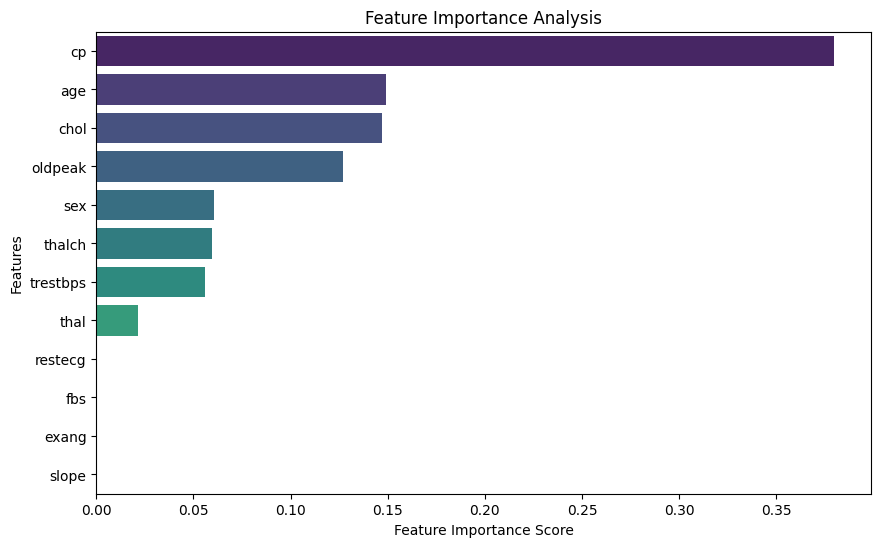

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature importance from the best decision tree model
feature_importance = best_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df['Importance'], y=feature_importance_df['Feature'], palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance Analysis")
plt.show()


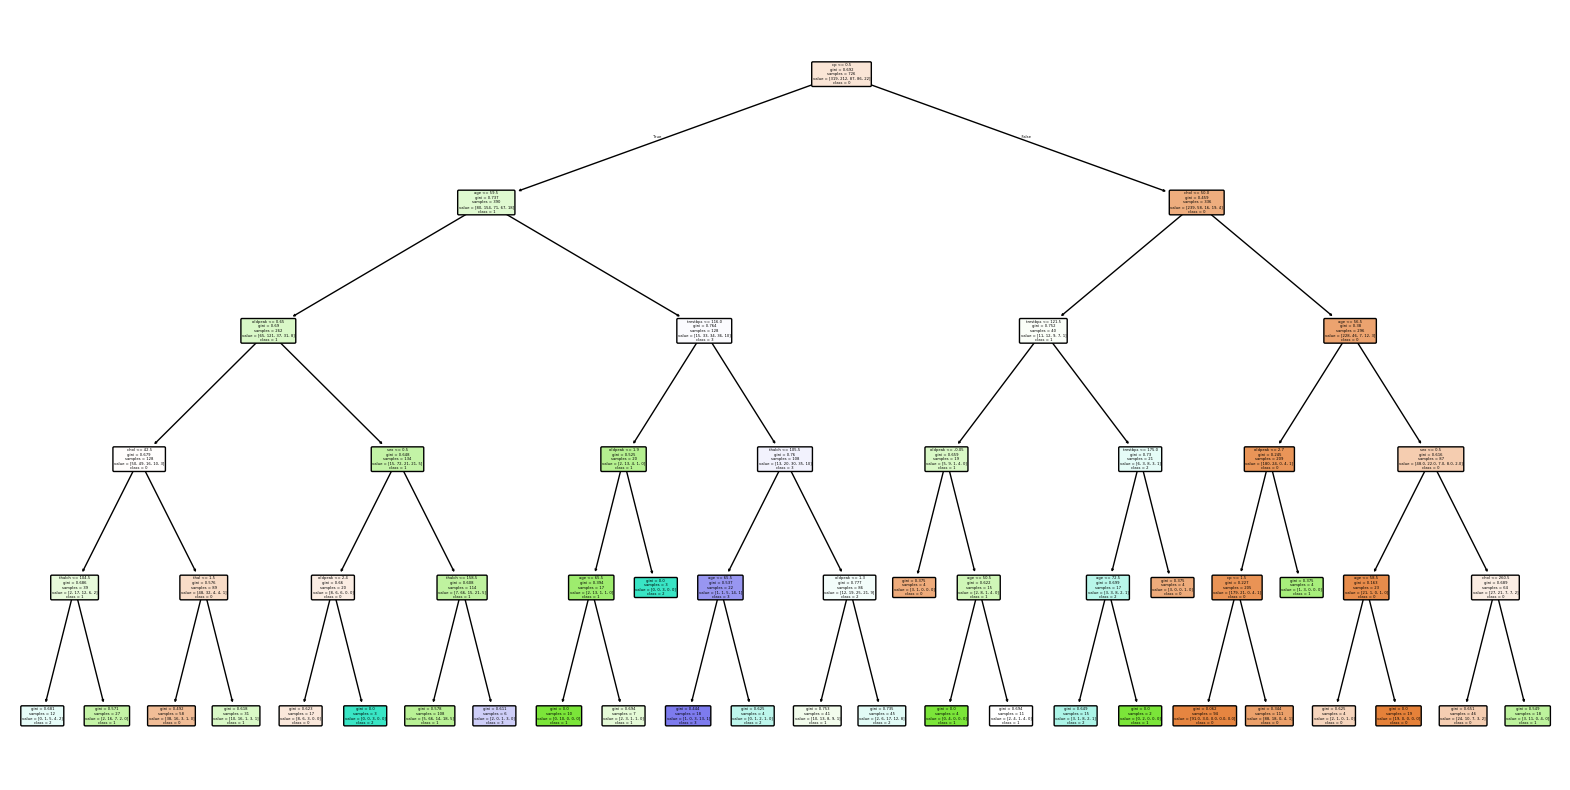

In [ ]:
from sklearn.tree import plot_tree

# Set figure size
plt.figure(figsize=(20, 10))

# Plot the decision tree
plot_tree(best_model, feature_names=X.columns, class_names=['0', '1', '2', '3', '4'], filled=True, rounded=True)

# Show the plot
plt.show()
